In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox
from prophet import Prophet
%matplotlib inline

C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_csv('daily_dallas.csv')

In [3]:
df.head()

,createddate,sales,sales_transformed
0,2021-01-01,104545.67,5.137405
1,2021-01-02,101959.89,5.133725
2,2021-01-03,105851.80,5.139224
3,2021-01-04,77273.75,5.091948
4,2021-01-05,72252.07,5.081529


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   createddate        1546 non-null   object 
 1   sales              1546 non-null   float64
 2   sales_transformed  1546 non-null   float64
dtypes: float64(2), object(1)
memory usage: 36.4+ KB


In [5]:
df['createddate']=pd.to_datetime(df['createddate'],format='%Y-%m-%d')
df.set_index('createddate',inplace=True)

<Axes: xlabel='createddate'>

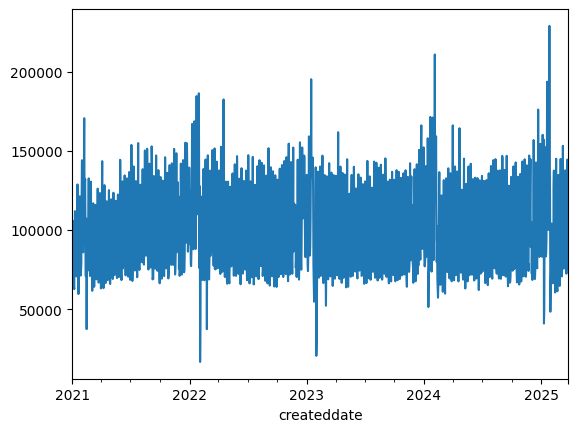

In [6]:
df['sales'].plot()

In [7]:
df[df['sales']>=150000]

,sales,sales_transformed
createddate,,
2021-02-07,170634.43,5.206400
2021-07-04,153751.79,5.192194
2021-07-25,154958.08,5.193268
2021-08-15,150261.66,5.189029
2021-08-22,151338.06,5.190014
2021-09-05,152860.55,5.191394
2021-11-14,151261.25,5.189944
2021-12-19,155148.93,5.193437
2021-12-24,154804.35,5.193131


<Axes: xlabel='createddate'>

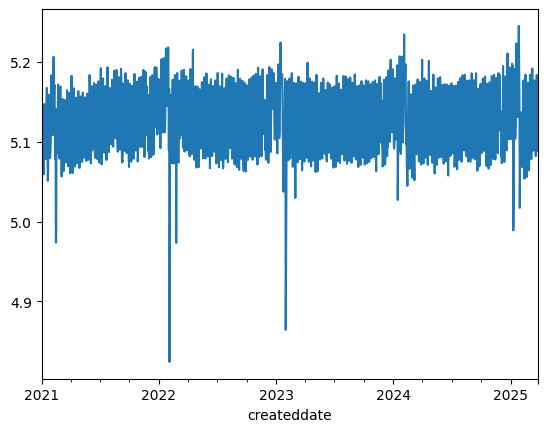

In [8]:
df['sales_transformed'].plot()

In [9]:
sales=df['sales']

In [10]:
sales_df=pd.DataFrame(sales)

In [11]:
sales_df.head()

,sales
createddate,
2021-01-01,104545.67
2021-01-02,101959.89
2021-01-03,105851.80
2021-01-04,77273.75
2021-01-05,72252.07


In [12]:
sales_df.reset_index(inplace=True)

In [13]:
sales_df.rename(columns={'createddate':'ds','sales':'y'},inplace=True)

In [14]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1546 non-null   datetime64[ns]
 1   y       1546 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 24.3 KB


In [25]:
sales_df['festive']=sales_df['ds'].dt.month.isin([12,1]).astype(int)
#sales_df['April']=sales_df['ds'].dt.month.isin([4]).astype(int)

In [16]:
sales_df['April']=sales_df['April']*100000

In [26]:
sales_df.head()

,ds,y,festive
0,2021-01-01,104545.67,1
1,2021-01-02,101959.89,1
2,2021-01-03,105851.80,1
3,2021-01-04,77273.75,1
4,2021-01-05,72252.07,1


In [117]:
train,test=sales_df[sales_df['ds']<='2024-12-31'],sales_df[sales_df['ds']>='2025-01-01']

In [28]:
train.head()

,ds,y,festive
0,2021-01-01,104545.67,1
1,2021-01-02,101959.89,1
2,2021-01-03,105851.80,1
3,2021-01-04,77273.75,1
4,2021-01-05,72252.07,1


In [29]:
train.isna().sum()

ds         0
y          0
festive    0
dtype: int64

In [118]:
test.head()

,ds,y,festive
1461,2025-01-01,123043.93,1
1462,2025-01-02,104379.69,1
1463,2025-01-03,83206.22,1
1464,2025-01-04,116833.69,1
1465,2025-01-05,160155.95,1


In [31]:
test.isna().sum()

ds         0
y          0
festive    0
dtype: int64

In [35]:
model = Prophet(
    growth='flat',seasonality_mode='additive',yearly_seasonality=True
)

# Add custom regressors
model.add_regressor('festive')

In [32]:
model = Prophet(
    growth='linear',seasonality_mode='multiplicative',yearly_seasonality=True,changepoint_prior_scale=1
)

# Add custom regressors
#model.add_regressor('April',prior_scale=100.0)
model.add_seasonality(
    name='dec_jan', 
    period=280,  # Yearly period
    fourier_order=10,  # Adjust based on complexity
    condition_name='festive'  # Only active when festive=1
)
'''''
model.add_seasonality(
    name='april', 
    period=30,  # Yearly period
    fourier_order=5,  # Adjust based on complexity
    condition_name='April'  # Only active when festive=1
)
'''''

"''\nmodel.add_seasonality(\n    name='april', \n    period=30,  # Yearly period\n    fourier_order=5,  # Adjust based on complexity\n    condition_name='April'  # Only active when festive=1\n)\n"

In [33]:
model.fit(train)

17:24:22 - cmdstanpy - INFO - Chain [1] start processing
17:24:23 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
future = model.make_future_dataframe(periods=90, freq='D')

# Add the same features to future
future['festive'] = future['ds'].dt.month.isin([12, 1]).astype(int)
#future['April'] = future['ds'].dt.month.isin([4]).astype(int)


In [617]:
future['April']=future['April']*100000

In [35]:
future.head()

,ds,festive
0,2021-01-01,1
1,2021-01-02,1
2,2021-01-03,1
3,2021-01-04,1
4,2021-01-05,1


In [36]:
forecast=model.predict(future)

In [37]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,dec_jan,dec_jan_lower,dec_jan_upper,multiplicative_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2021-01-01,88736.575761,67112.756200,98281.956270,88736.575761,88736.575761,-0.155654,-0.155654,-0.155654,-0.065423,...,-0.115044,-0.115044,-0.115044,0.205274,0.205274,0.205274,0.0,0.0,0.0,82931.130283
1,2021-01-02,88743.997183,93544.391435,123089.469659,88743.997183,88743.997183,-0.165349,-0.165349,-0.165349,0.216833,...,0.173474,0.173474,0.173474,0.208708,0.208708,0.208708,0.0,0.0,0.0,107986.628110
2,2021-01-03,88751.418606,119086.926852,149931.694417,88751.418606,88751.418606,-0.176007,-0.176007,-0.176007,0.513091,...,0.478188,0.478188,0.478188,0.210911,0.210911,0.210911,0.0,0.0,0.0,134289.001636
3,2021-01-04,88758.840028,69389.563360,98740.063303,88758.840028,88758.840028,-0.187064,-0.187064,-0.187064,-0.051465,...,-0.076349,-0.076349,-0.076349,0.211947,0.211947,0.211947,0.0,0.0,0.0,84190.831649
4,2021-01-05,88766.261451,67958.496206,98830.960232,88766.261451,88766.261451,-0.197951,-0.197951,-0.197951,-0.068637,...,-0.082593,-0.082593,-0.082593,0.211907,0.211907,0.211907,0.0,0.0,0.0,82673.568887


<Axes: xlabel='ds'>

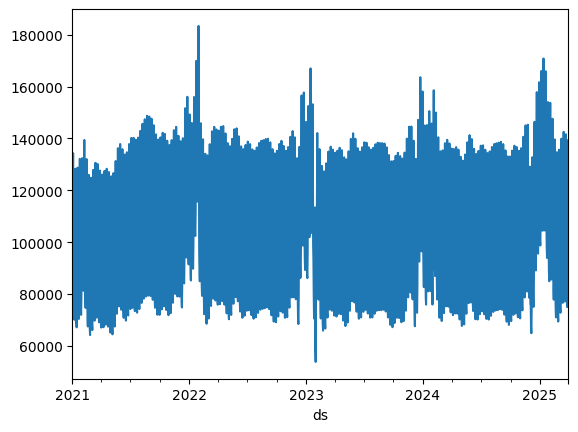

In [38]:
forecast.set_index('ds')['yhat'].plot()

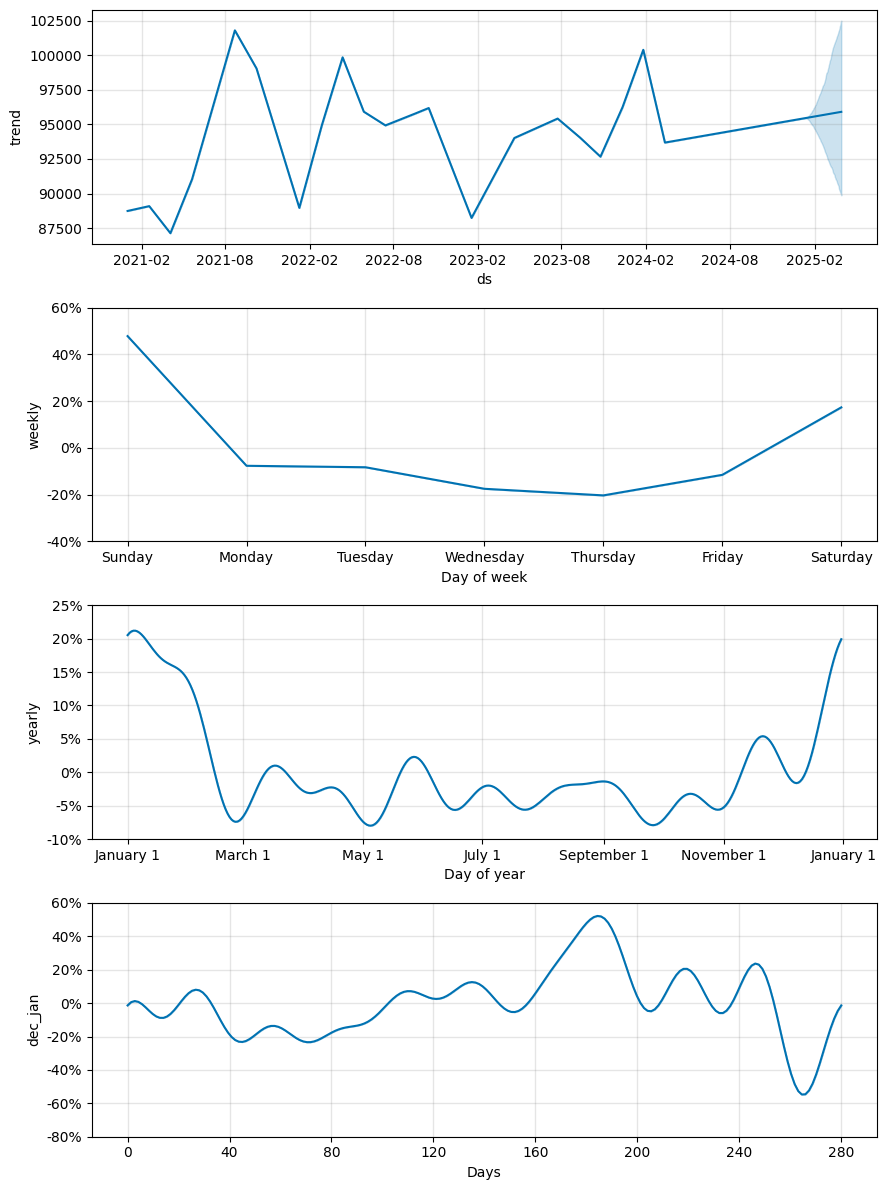

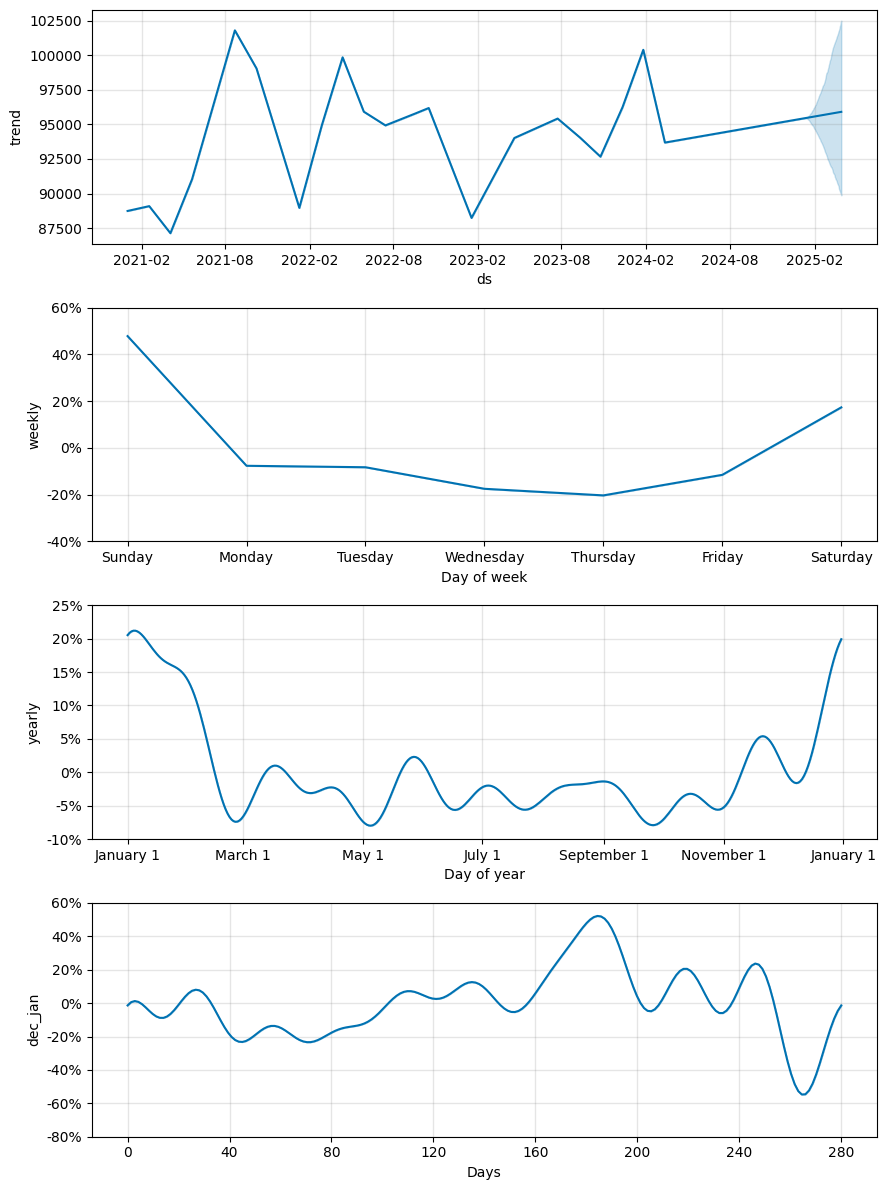

In [39]:
from prophet.plot import plot_components
model.plot_components(forecast)

In [416]:
test.head()

,ds,y,festive,April
1461,2025-01-01,123043.93,1,0
1462,2025-01-02,104379.69,1,0
1463,2025-01-03,83206.22,1,0
1464,2025-01-04,116833.69,1,0
1465,2025-01-05,160155.95,1,0


In [405]:
train[train['y']>=160000]

,ds,y,festive,April
37,2021-02-07,170634.43,0,0
373,2022-01-09,167006.28,1,0
380,2022-01-16,168677.48,1,0
387,2022-01-23,184584.51,1,0
394,2022-01-30,186342.34,1,0
471,2022-04-17,182456.30,0,1
744,2023-01-15,195231.41,1,0
828,2023-04-09,161793.28,0,1
1087,2023-12-24,166142.39,1,0
1115,2024-01-21,171410.33,1,0


In [258]:
test[test['y']>=160000]

,ds,y,festive
1465,2025-01-05,160155.95,1
1479,2025-01-19,193655.02,1
1486,2025-01-26,228869.54,1


In [41]:
forecast[forecast['yhat']>=160000]

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,dec_jan,dec_jan_lower,dec_jan_upper,multiplicative_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
387,2022-01-23,90678.446139,154637.904244,184634.491068,90678.446139,90678.446139,0.234167,0.234167,0.234167,0.873675,...,0.478188,0.478188,0.478188,0.161320,0.161320,0.161320,0.0,0.0,0.0,169901.907766
394,2022-01-30,91538.080356,168273.693613,199300.300548,91538.080356,91538.080356,0.378693,0.378693,0.378693,1.003343,...,0.478188,0.478188,0.478188,0.146463,0.146463,0.146463,0.0,0.0,0.0,183382.195542
744,2023-01-15,88488.725302,152687.424204,181040.248272,88488.725302,88488.725302,0.226918,0.226918,0.226918,0.887185,...,0.478188,0.478188,0.478188,0.182079,0.182079,0.182079,0.0,0.0,0.0,166994.594443
1087,2023-12-24,97356.197563,147871.515952,178137.238683,97356.197563,97356.197563,0.077334,0.077334,0.077334,0.680373,...,0.478188,0.478188,0.478188,0.124851,0.124851,0.124851,0.0,0.0,0.0,163594.766656
1458,2024-12-29,95374.049819,146386.755004,177474.198634,95374.049819,95374.049819,0.029511,0.029511,0.029511,0.695016,...,0.478188,0.478188,0.478188,0.187317,0.187317,0.187317,0.0,0.0,0.0,161660.498164
1465,2025-01-05,95414.693085,149655.054747,180322.187782,95414.693085,95414.693085,0.049659,0.049659,0.049659,0.739754,...,0.478188,0.478188,0.478188,0.211907,0.211907,0.211907,0.0,0.0,0.0,165998.105632
1472,2025-01-12,95455.336352,155543.761847,185999.419774,95455.336352,95455.336352,0.119387,0.119387,0.119387,0.789506,...,0.478188,0.478188,0.478188,0.191931,0.191931,0.191931,0.0,0.0,0.0,170817.887786
1479,2025-01-19,95495.979618,151142.704008,180590.007440,95321.292801,95612.995039,0.090912,0.090912,0.090912,0.737304,...,0.478188,0.478188,0.478188,0.168204,0.168204,0.168204,0.0,0.0,0.0,165905.543531


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
merged = test.merge(forecast[['ds', 'yhat']], on='ds')

# Calculate metrics
mae = mean_absolute_error(merged['y'], merged['yhat'])
mse = mean_squared_error(merged['y'], merged['yhat'])
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(merged['y'], merged['yhat']) * 100

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAPE: {mape:.2f}%')

MAE: 14646.578
RMSE: 21532.164
MAPE: 16.84%


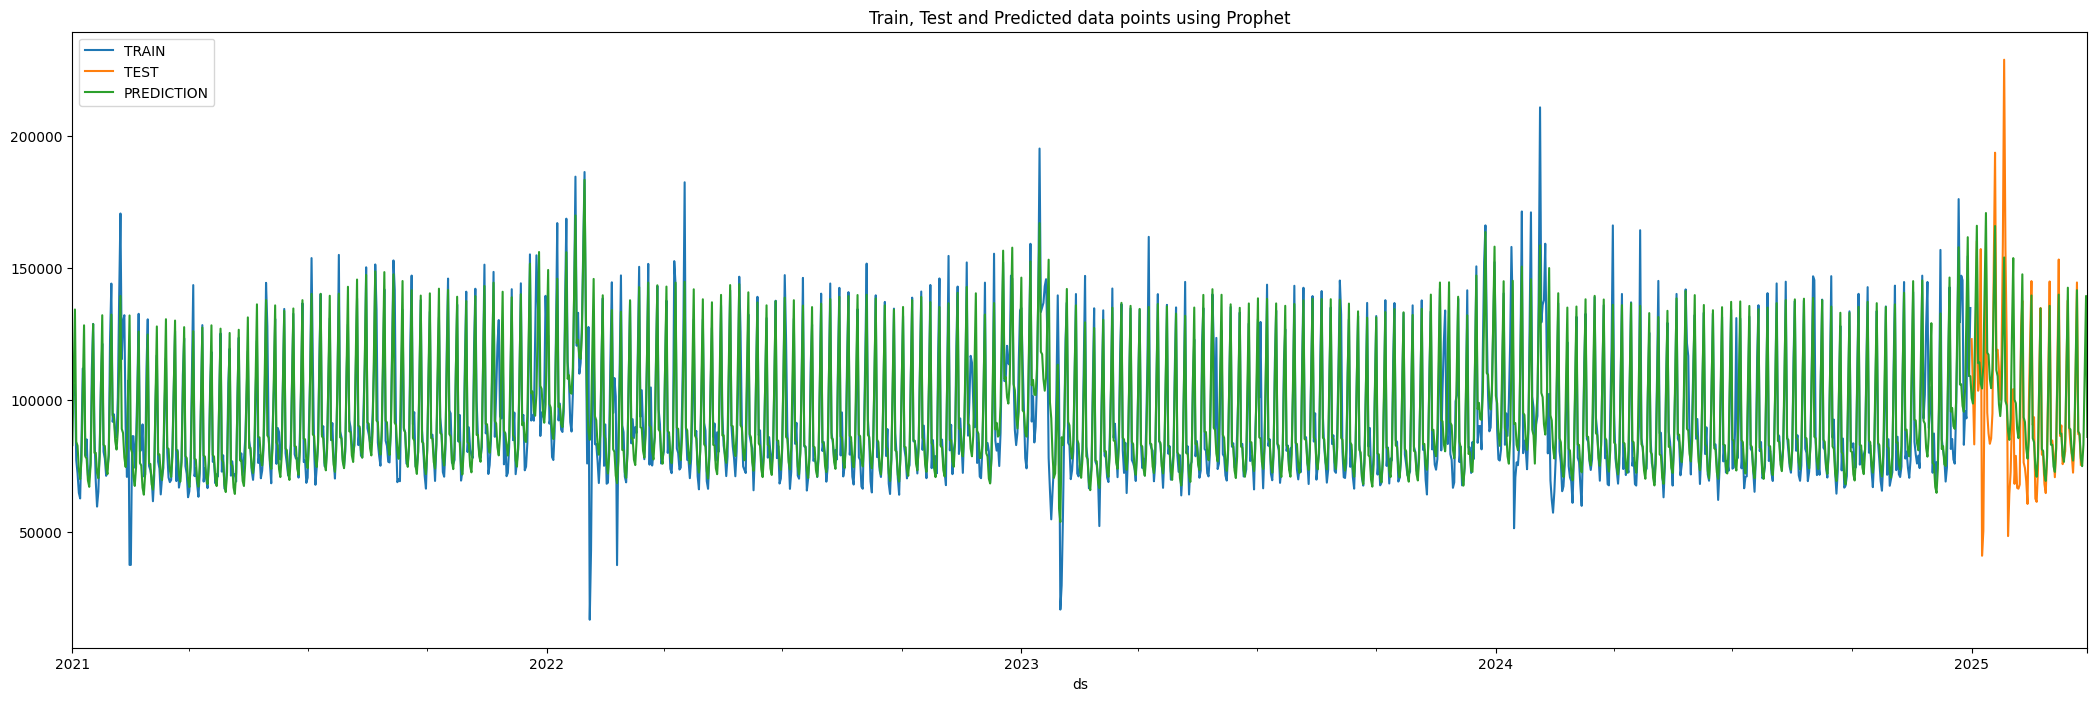

In [43]:
train.set_index('ds')['y'].plot(legend=True,label='TRAIN',figsize=(26,8))
test.set_index('ds')['y'].plot(legend=True,label='TEST',figsize=(26,8))
forecast.set_index('ds')['yhat'].plot(legend=True,label='PREDICTION',figsize=(26,8))
plt.title('Train, Test and Predicted data points using Prophet')
plt.show()

<Axes: xlabel='ds'>

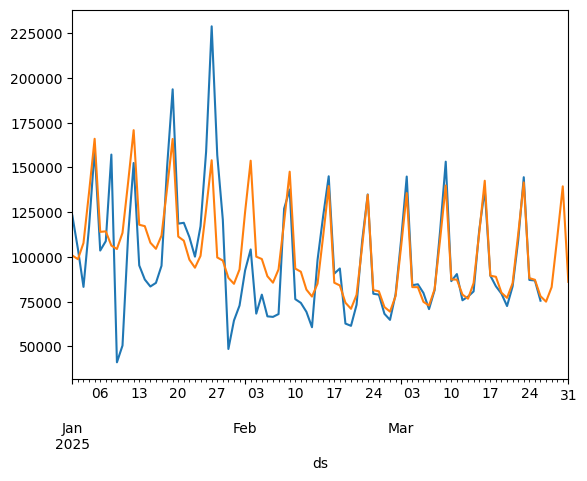

In [44]:
test.set_index('ds')['y'].plot()
forecast[forecast['ds']>='2025-01-01'].set_index('ds')['yhat'].plot()

<Axes: xlabel='createddate'>

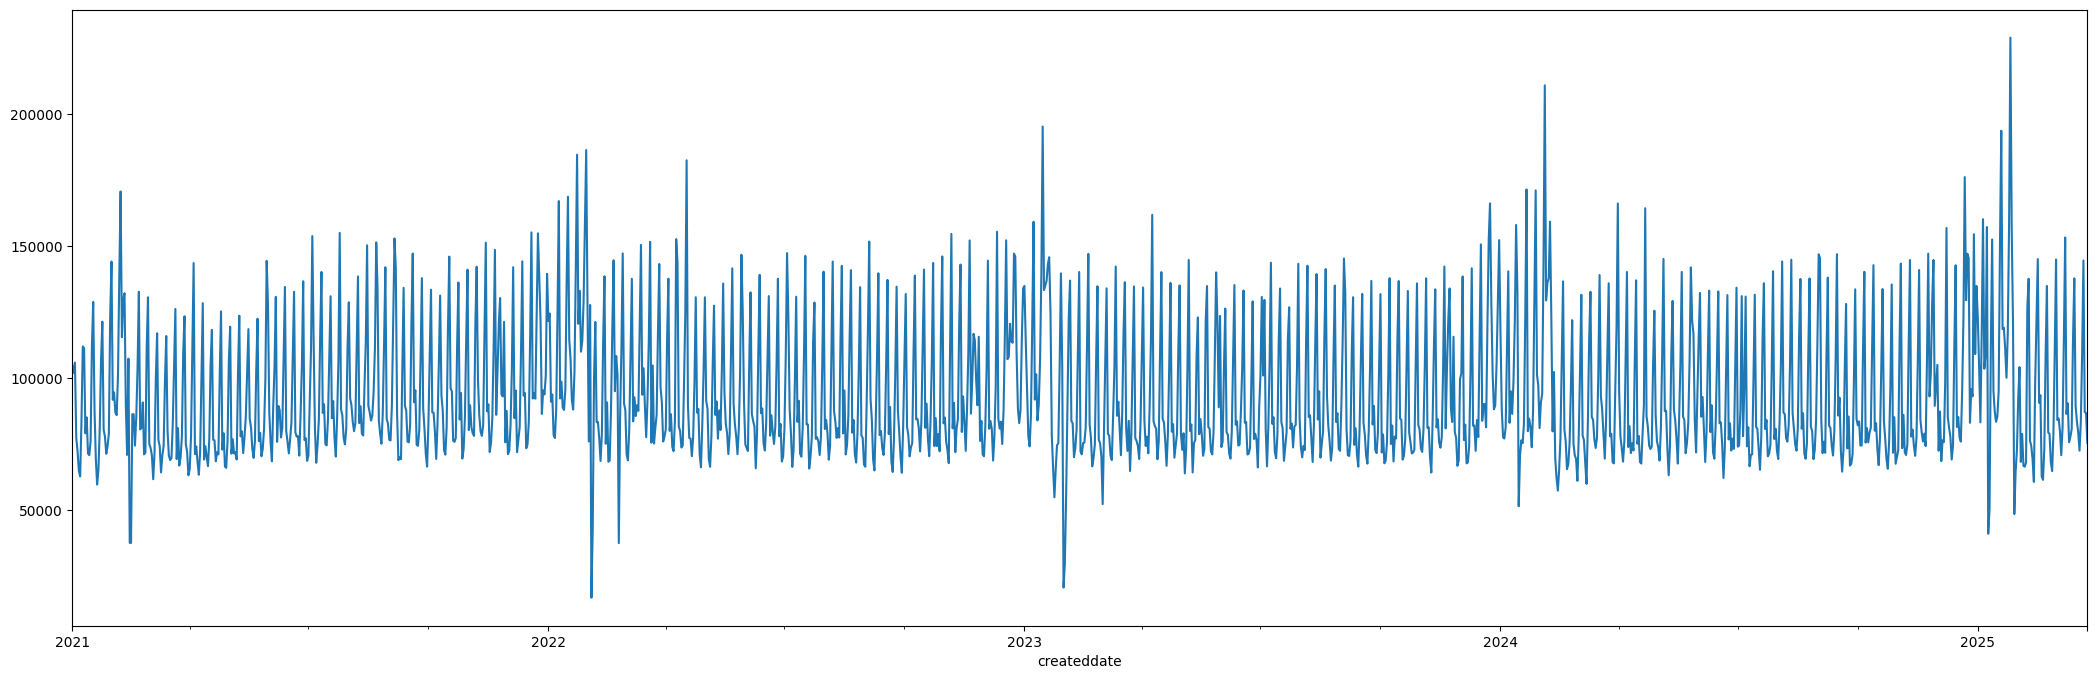

In [328]:
df['sales'].plot(figsize=(26,8))

In [49]:
df[df['sales']<=65000]

,sales,sales_transformed
createddate,,
2021-01-06,64846.60,5.064516
2021-01-07,62738.67,5.059255
2021-01-20,59652.01,5.051168
2021-02-14,37570.65,4.973821
2021-02-15,37570.65,4.973821
2021-03-04,61679.67,5.056534
2021-03-10,64261.61,5.063076
2021-03-31,63196.03,5.060414
2021-04-08,63368.66,5.060849


<Axes: xlabel='createddate'>

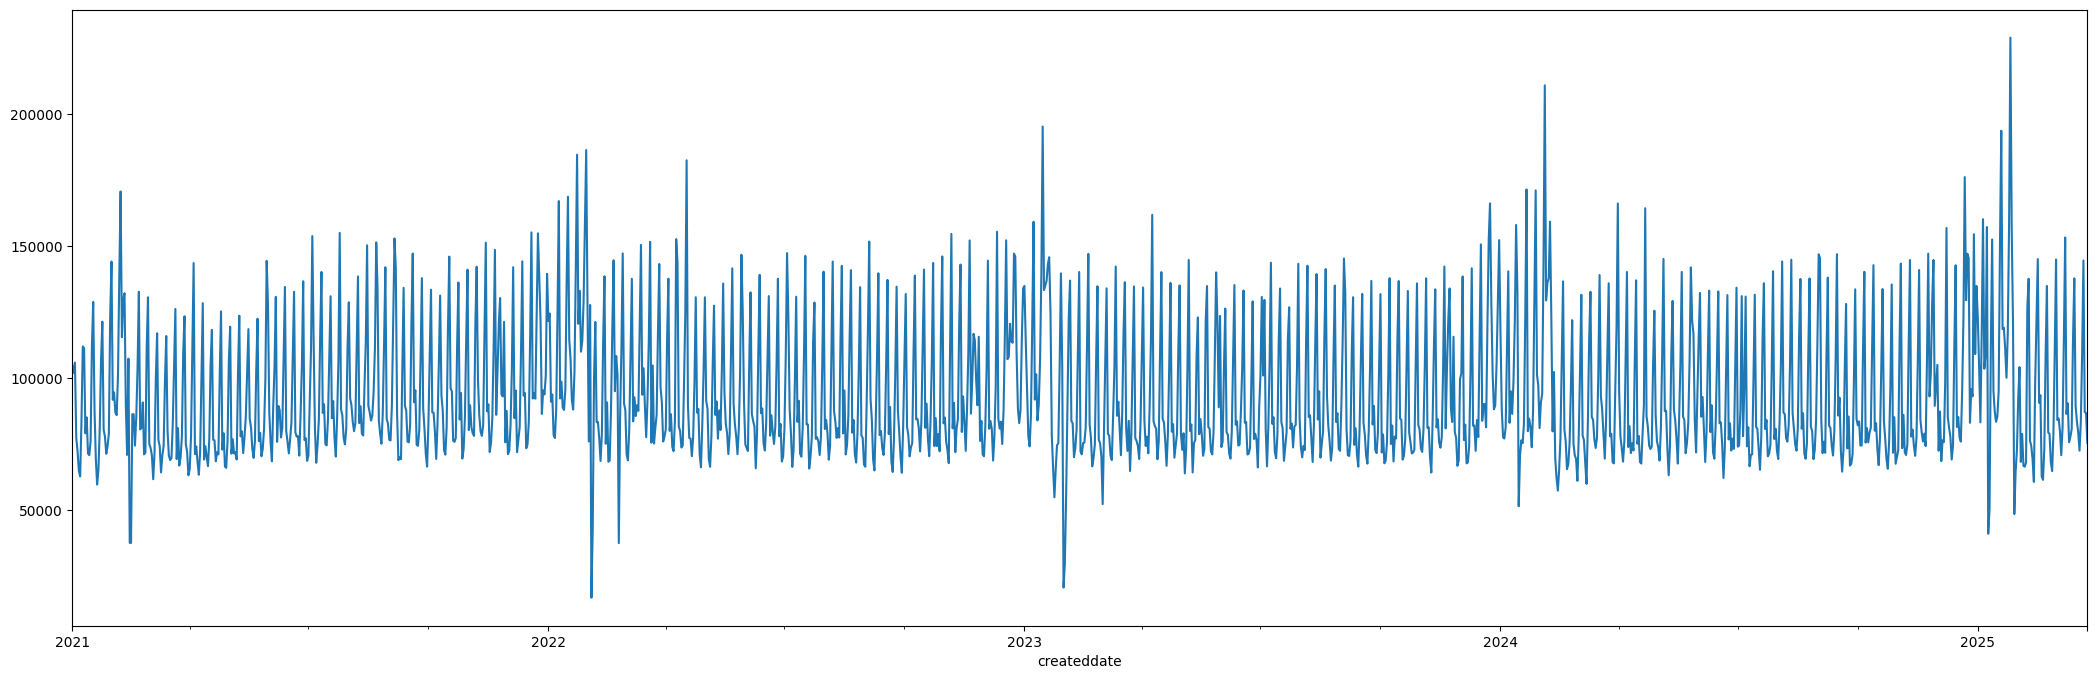

In [44]:
df['sales'].plot(figsize=(26,8))

In [48]:
df[df['sales']<60000]['sales']

createddate
2021-01-20    59652.01
2021-02-14    37570.65
2021-02-15    37570.65
2022-02-03    16809.36
2022-02-04    43209.73
2022-02-24    37487.71
2023-01-24    54822.13
2023-01-31    20650.08
2023-02-01    29816.24
2023-02-02    56012.42
2023-03-02    52274.46
2024-01-15    51452.92
2024-02-14    57343.58
2024-03-07    59926.62
2025-01-09    41035.07
2025-01-10    50415.88
2025-01-29    48492.95
Name: sales, dtype: float64

In [15]:
sales_transformed=df['sales_transformed']

In [16]:
sales_transformed.head()

createddate
2021-01-01    5.137405
2021-01-02    5.133725
2021-01-03    5.139224
2021-01-04    5.091948
2021-01-05    5.081529
Name: sales_transformed, dtype: float64

In [17]:
sales_transformed_df=pd.DataFrame(sales_transformed)

In [18]:
sales_transformed_df.head()

,sales_transformed
createddate,
2021-01-01,5.137405
2021-01-02,5.133725
2021-01-03,5.139224
2021-01-04,5.091948
2021-01-05,5.081529


In [19]:
sales_transformed_df.reset_index(inplace=True)

In [20]:
sales_transformed_df.rename(columns={'createddate':'ds','sales_transformed':'y'},inplace=True)

In [21]:
sales_transformed_df.head()

,ds,y
0,2021-01-01,5.137405
1,2021-01-02,5.133725
2,2021-01-03,5.139224
3,2021-01-04,5.091948
4,2021-01-05,5.081529


In [22]:
sales_transformed_df['festive']=sales_df['ds'].dt.month.isin([12,1]).astype(int)
sales_transformed_df['april']=sales_df['ds'].dt.month.isin([4]).astype(int)


In [23]:
model = Prophet(
    growth='linear',seasonality_mode='multiplicative',yearly_seasonality=True,changepoint_prior_scale=0.5
)

# Add custom regressors
#model.add_regressor('April',prior_scale=100.0)
model.add_seasonality(
    name='dec_jan', 
    period=280,  # Yearly period
    fourier_order=3,  # Adjust based on complexity
    condition_name='festive'  # Only active when festive=1
)


model.add_seasonality(
    name='apr', 
    period=280,  # Yearly period
    fourier_order=3,  # Adjust based on complexity
    condition_name='april'  # Only active when festive=1
)


In [24]:
sales_transformed_df.head()

,ds,y,festive,april
0,2021-01-01,5.137405,1,0
1,2021-01-02,5.133725,1,0
2,2021-01-03,5.139224,1,0
3,2021-01-04,5.091948,1,0
4,2021-01-05,5.081529,1,0


In [25]:
sales_transformed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   ds       1546 non-null   datetime64[ns]
 1   y        1546 non-null   float64       
 2   festive  1546 non-null   int32         
 3   april    1546 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 36.4 KB


In [26]:
train,test=sales_transformed_df[sales_transformed_df['ds']<='2024-12-31'],sales_transformed_df[sales_transformed_df['ds']>='2025-01-01']

In [27]:
model.fit(train)

10:14:08 - cmdstanpy - INFO - Chain [1] start processing
10:14:10 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
future = model.make_future_dataframe(periods=90, freq='D')

# Add the same features to future
future['festive'] = future['ds'].dt.month.isin([12, 1]).astype(int)
future['april'] = future['ds'].dt.month.isin([2]).astype(int)

In [29]:
future.tail()

,ds,festive,april
1546,2025-03-27,0,0
1547,2025-03-28,0,0
1548,2025-03-29,0,0
1549,2025-03-30,0,0
1550,2025-03-31,0,0


In [30]:
forecast=model.predict(future)

In [31]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,apr,apr_lower,apr_upper,dec_jan,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
1546,2025-03-27,5.121228,5.021633,5.145386,5.061420,5.172657,0.0,0.0,0.0,0.0,...,-0.006245,-0.006245,-0.006245,-0.000254,-0.000254,-0.000254,0.0,0.0,0.0,5.087941
1547,2025-03-28,5.121250,5.041477,5.164432,5.060290,5.173610,0.0,0.0,0.0,0.0,...,-0.002757,-0.002757,-0.002757,-0.000254,-0.000254,-0.000254,0.0,0.0,0.0,5.105831
1548,2025-03-29,5.121273,5.080987,5.209478,5.058546,5.174773,0.0,0.0,0.0,0.0,...,0.005626,0.005626,0.005626,-0.000249,-0.000249,-0.000249,0.0,0.0,0.0,5.148811
1549,2025-03-30,5.121296,5.112039,5.243737,5.057273,5.175703,0.0,0.0,0.0,0.0,...,0.011938,0.011938,0.011938,-0.000239,-0.000239,-0.000239,0.0,0.0,0.0,5.181213
1550,2025-03-31,5.121319,5.040125,5.168225,5.055797,5.176616,0.0,0.0,0.0,0.0,...,-0.001693,-0.001693,-0.001693,-0.000223,-0.000223,-0.000223,0.0,0.0,0.0,5.111509


<Axes: xlabel='ds'>

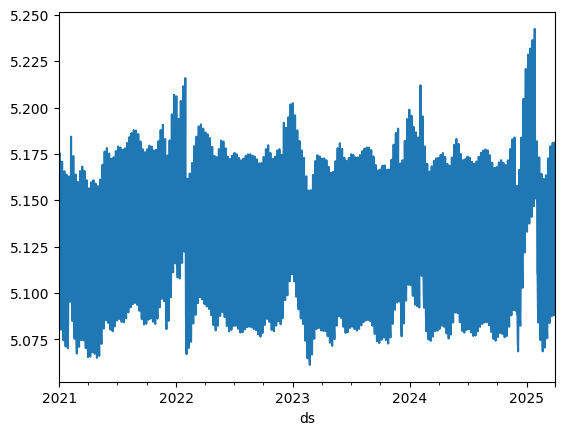

In [32]:
forecast.set_index('ds')['yhat'].plot()

In [388]:
train.head()

,ds,y,festive,april
0,2021-01-01,5.137405,1,0
1,2021-01-02,5.133725,1,0
2,2021-01-03,5.139224,1,0
3,2021-01-04,5.091948,1,0
4,2021-01-05,5.081529,1,0


In [389]:
test.head()

,ds,y,festive,april
1461,2025-01-01,5.160975,1,0
1462,2025-01-02,5.137172,1,0
1463,2025-01-03,5.103284,1,0
1464,2025-01-04,5.153552,1,0
1465,2025-01-05,5.197787,1,0


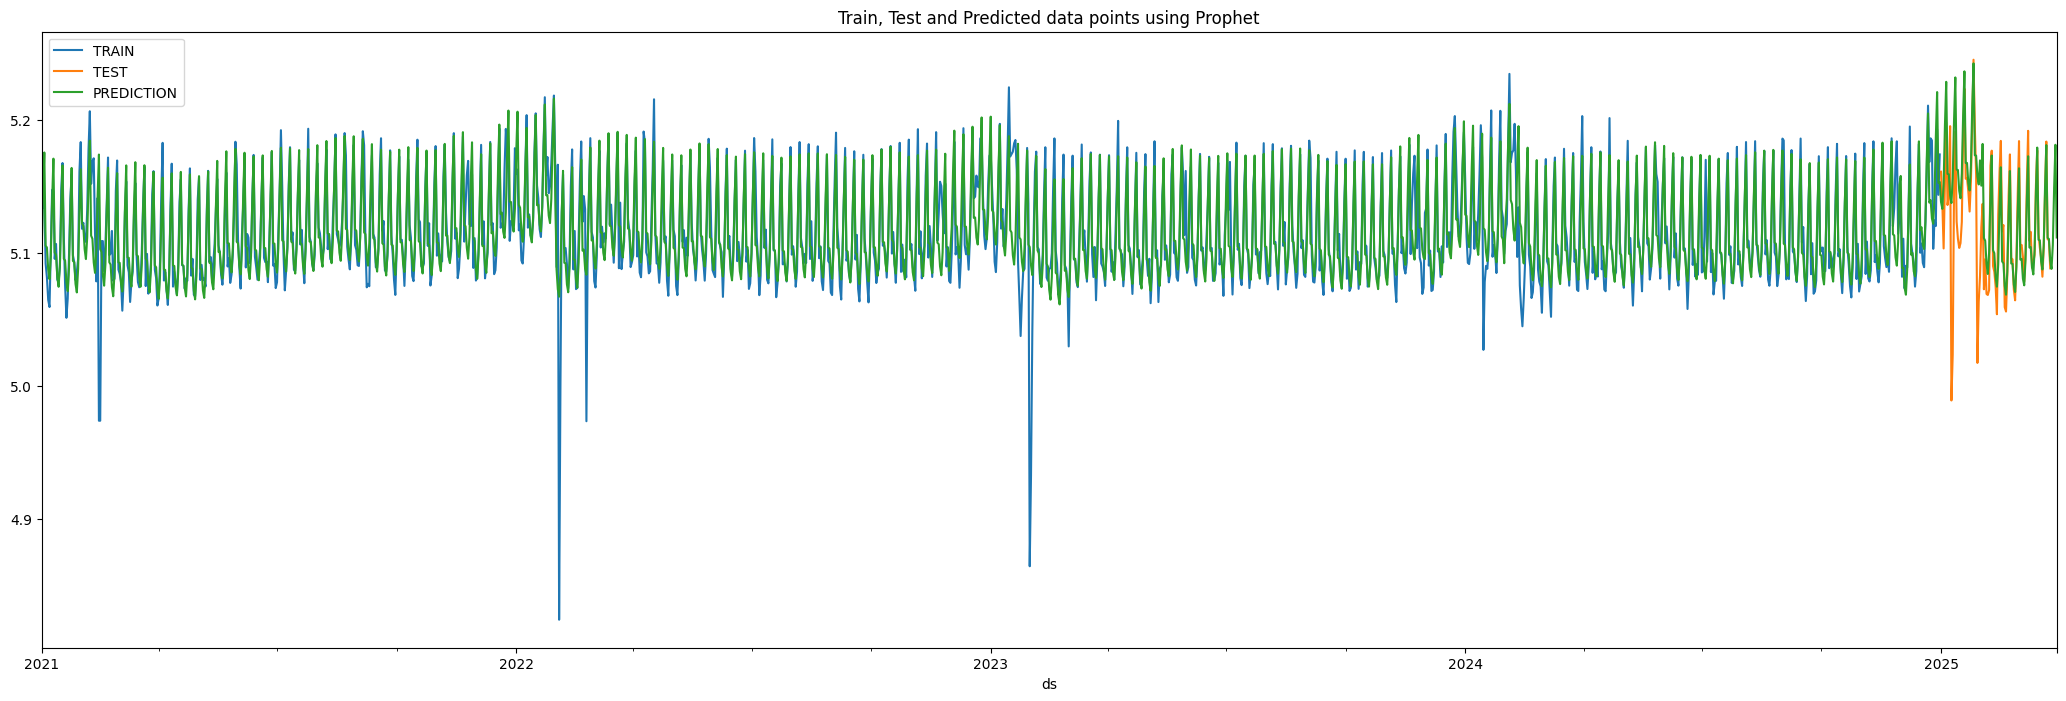

In [33]:
train.set_index('ds')['y'].plot(legend=True,label='TRAIN',figsize=(26,8))
test.set_index('ds')['y'].plot(legend=True,label='TEST',figsize=(26,8))
forecast.set_index('ds')['yhat'].plot(legend=True,label='PREDICTION',figsize=(26,8))
plt.title('Train, Test and Predicted data points using Prophet')
plt.show()

In [391]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,apr,apr_lower,apr_upper,dec_jan,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
1546,2025-03-27,5.121228,5.021309,5.139400,5.062288,5.173671,0.0,0.0,0.0,0.0,...,-0.006245,-0.006245,-0.006245,-0.000254,-0.000254,-0.000254,0.0,0.0,0.0,5.087941
1547,2025-03-28,5.121250,5.038106,5.165146,5.060333,5.174757,0.0,0.0,0.0,0.0,...,-0.002757,-0.002757,-0.002757,-0.000254,-0.000254,-0.000254,0.0,0.0,0.0,5.105831
1548,2025-03-29,5.121273,5.080987,5.205592,5.059563,5.175825,0.0,0.0,0.0,0.0,...,0.005626,0.005626,0.005626,-0.000249,-0.000249,-0.000249,0.0,0.0,0.0,5.148811
1549,2025-03-30,5.121296,5.111319,5.238938,5.058832,5.176858,0.0,0.0,0.0,0.0,...,0.011938,0.011938,0.011938,-0.000239,-0.000239,-0.000239,0.0,0.0,0.0,5.181213
1550,2025-03-31,5.121319,5.042394,5.169403,5.057875,5.177470,0.0,0.0,0.0,0.0,...,-0.001693,-0.001693,-0.001693,-0.000223,-0.000223,-0.000223,0.0,0.0,0.0,5.111509


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
merged = test.merge(forecast[['ds', 'yhat']], on='ds')

# Calculate metrics
mae = mean_absolute_error(merged['y'], merged['yhat'])
mse = mean_squared_error(merged['y'], merged['yhat'])
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(merged['y'], merged['yhat']) * 100

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAPE: {mape:.2f}%')

MAE: 0.023
RMSE: 0.036
MAPE: 0.45%


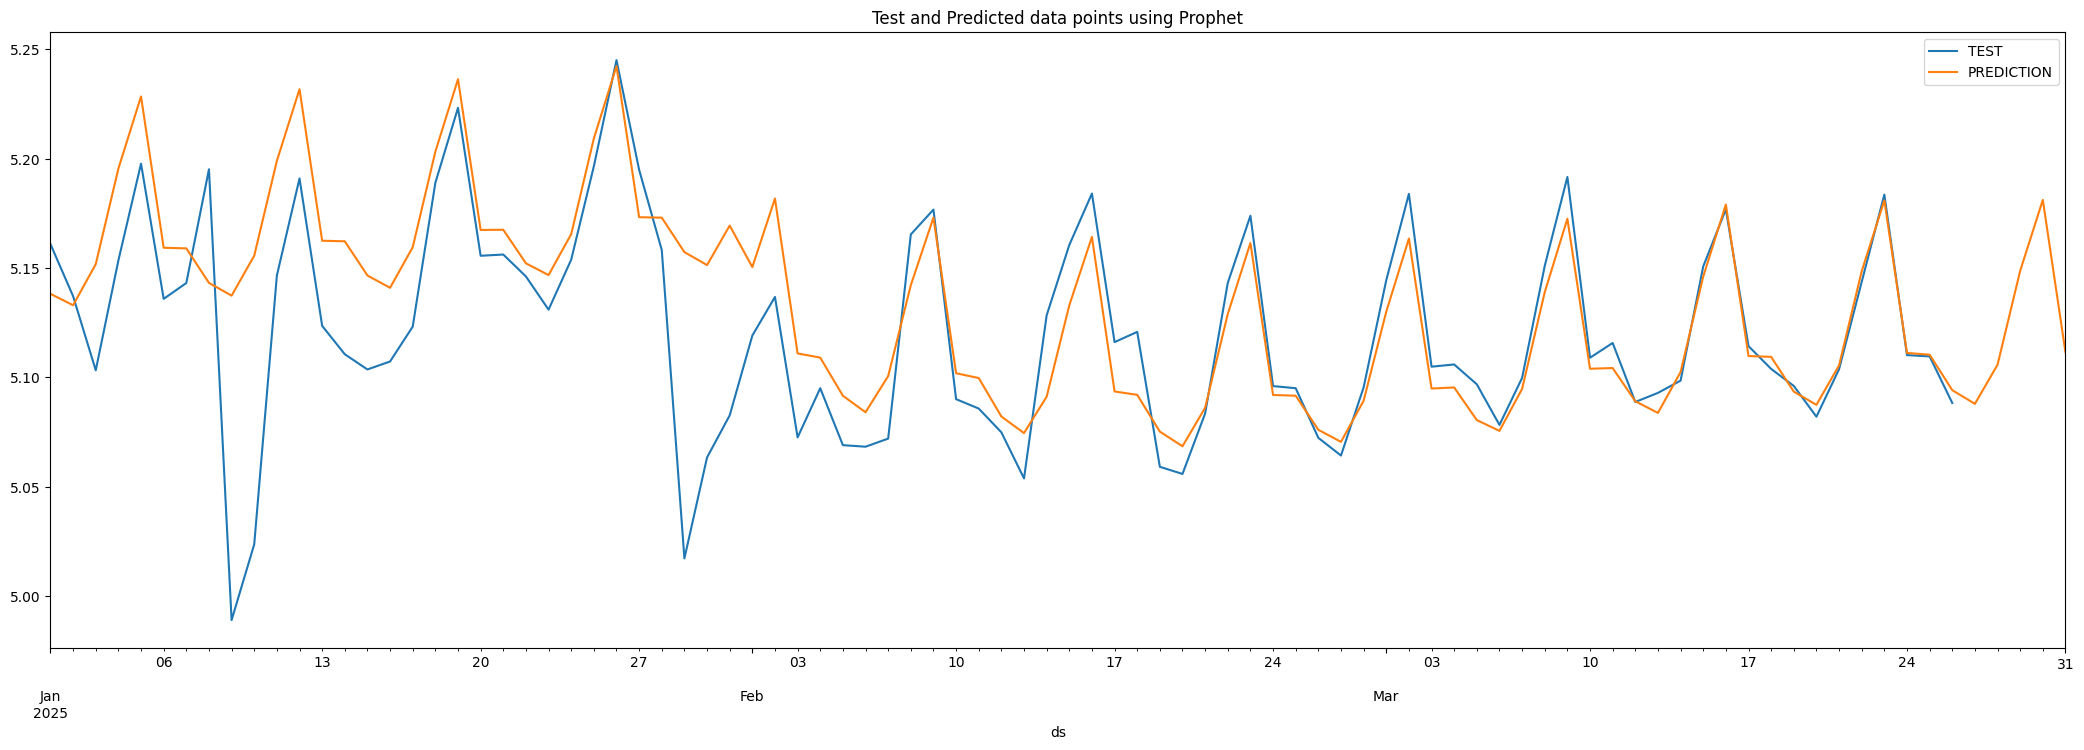

In [35]:
test.set_index('ds')['y'].plot(legend=True,label='TEST',figsize=(26,8))
forecast[forecast['ds']>'2024-12-31'].set_index('ds')['yhat'].plot(legend=True,label='PREDICTION',figsize=(26,8))
plt.title('Test and Predicted data points using Prophet')
plt.show()

In [394]:
forecast.head(8)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,apr,apr_lower,apr_upper,dec_jan,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2021-01-01,5.113222,5.073824,5.125470,5.113222,5.113222,0.0,0.0,0.0,-0.007090,...,-0.002757,-0.002757,-0.002757,0.007359,0.007359,0.007359,0.0,0.0,0.0,5.100500
1,2021-01-02,5.113571,5.116853,5.169726,5.113571,5.113571,0.0,0.0,0.0,-0.007026,...,0.005626,0.005626,0.005626,0.007221,0.007221,0.007221,0.0,0.0,0.0,5.143341
2,2021-01-03,5.113920,5.147616,5.201941,5.113920,5.113920,0.0,0.0,0.0,-0.006961,...,0.011938,0.011938,0.011938,0.007048,0.007048,0.007048,0.0,0.0,0.0,5.175420
3,2021-01-04,5.114268,5.079778,5.132048,5.114268,5.114268,0.0,0.0,0.0,-0.006895,...,-0.001693,-0.001693,-0.001693,0.006844,0.006844,0.006844,0.0,0.0,0.0,5.105348
4,2021-01-05,5.114617,5.077223,5.131618,5.114617,5.114617,0.0,0.0,0.0,-0.006830,...,-0.001849,-0.001849,-0.001849,0.006612,0.006612,0.006612,0.0,0.0,0.0,5.104045
5,2021-01-06,5.114966,5.059645,5.115279,5.114966,5.114966,0.0,0.0,0.0,-0.006764,...,-0.005020,-0.005020,-0.005020,0.006357,0.006357,0.006357,0.0,0.0,0.0,5.087208
6,2021-01-07,5.115314,5.055116,5.108279,5.115314,5.115314,0.0,0.0,0.0,-0.006699,...,-0.006245,-0.006245,-0.006245,0.006084,0.006084,0.006084,0.0,0.0,0.0,5.080223
7,2021-01-08,5.115663,5.071333,5.124841,5.115663,5.115663,0.0,0.0,0.0,-0.006634,...,-0.002757,-0.002757,-0.002757,0.005798,0.005798,0.005798,0.0,0.0,0.0,5.097283


In [395]:
test.head()

,ds,y,festive,april
1461,2025-01-01,5.160975,1,0
1462,2025-01-02,5.137172,1,0
1463,2025-01-03,5.103284,1,0
1464,2025-01-04,5.153552,1,0
1465,2025-01-05,5.197787,1,0


In [396]:
df.head()

,sales,sales_transformed
createddate,,
2021-01-01,104545.67,5.137405
2021-01-02,101959.89,5.133725
2021-01-03,105851.80,5.139224
2021-01-04,77273.75,5.091948
2021-01-05,72252.07,5.081529


In [36]:
from scipy.stats import boxcox
from scipy.special import inv_boxcox


#y_transformed, lambda_value = boxcox(df['sales'])
lambda_value= -0.16610674492048902
print(lambda_value)
y__forecast = inv_boxcox(forecast['yhat'], lambda_value)


-0.16610674492048902


In [279]:
len(y__forecast)

1551

In [280]:
len(train)

1461

In [96]:
len(test)

85

In [37]:
forecast['y_inv_boxcox']=pd.Series(y__forecast)

<Axes: xlabel='ds'>

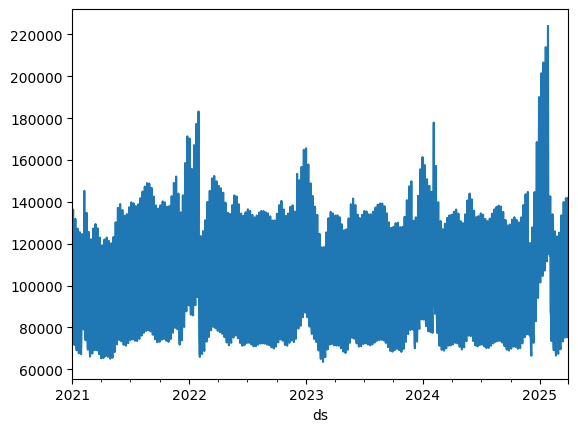

In [38]:
forecast.set_index('ds')['y_inv_boxcox'].plot()

In [401]:
df.head()

,sales,sales_transformed
createddate,,
2021-01-01,104545.67,5.137405
2021-01-02,101959.89,5.133725
2021-01-03,105851.80,5.139224
2021-01-04,77273.75,5.091948
2021-01-05,72252.07,5.081529


,ds,y,festive,april
0,2021-01-01,5.137405,1,0
1,2021-01-02,5.133725,1,0
2,2021-01-03,5.139224,1,0
3,2021-01-04,5.091948,1,0
4,2021-01-05,5.081529,1,0


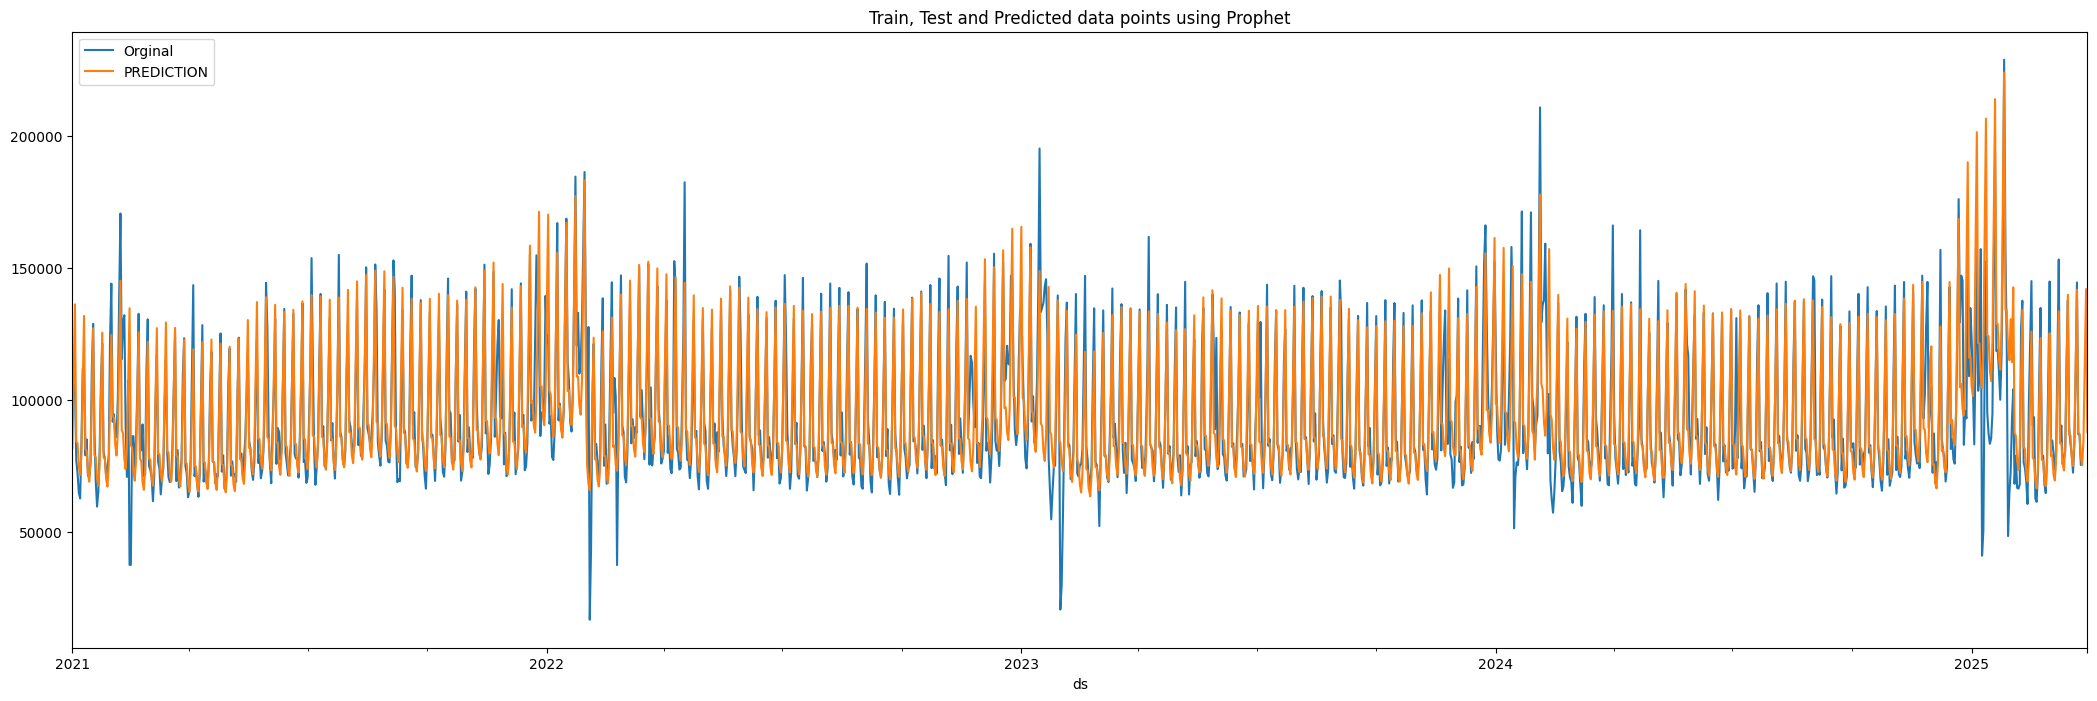

In [39]:
#train.set_index('ds')['y'].plot(legend=True,label='TRAIN',figsize=(26,8))
#test.set_index('ds')['y'].plot(legend=True,label='TEST',figsize=(26,8))
df['sales'].plot(legend=True,label='Orginal',figsize=(26,8))
forecast.set_index('ds')['y_inv_boxcox'].plot(legend=True,label='PREDICTION',figsize=(26,8))
plt.title('Train, Test and Predicted data points using Prophet')
plt.show()

In [284]:
test.head()

,ds,y,festive
1461,2025-01-01,5.160975,1
1462,2025-01-02,5.137172,1
1463,2025-01-03,5.103284,1
1464,2025-01-04,5.153552,1
1465,2025-01-05,5.197787,1


In [285]:
test.head(20)

,ds,y,festive
1461,2025-01-01,5.160975,1
1462,2025-01-02,5.137172,1
1463,2025-01-03,5.103284,1
1464,2025-01-04,5.153552,1
1465,2025-01-05,5.197787,1
1466,2025-01-06,5.135956,1
1467,2025-01-07,5.143212,1
1468,2025-01-08,5.195208,1
1469,2025-01-09,4.989040,1
1470,2025-01-10,5.023708,1


In [286]:
forecast.head(20)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,dec_jan,dec_jan_lower,dec_jan_upper,multiplicative_terms,...,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat,y_inv_boxcox
0,2021-01-01,5.112092,5.074124,5.127734,5.112092,5.112092,-0.006694,-0.006694,-0.006694,-0.002277,...,-0.002758,-0.002758,0.007175,0.007175,0.007175,0.0,0.0,0.0,5.100450,81674.924282
1,2021-01-02,5.112393,5.117528,5.170570,5.112393,5.112393,-0.006643,-0.006643,-0.006643,0.006041,...,0.005626,0.005626,0.007058,0.007058,0.007058,0.0,0.0,0.0,5.143278,108832.107809
2,2021-01-03,5.112694,5.147223,5.202612,5.112694,5.112694,-0.006592,-0.006592,-0.006592,0.012258,...,0.011943,0.011943,0.006907,0.006907,0.006907,0.0,0.0,0.0,5.175367,136214.457817
3,2021-01-04,5.112995,5.079450,5.134353,5.112995,5.112995,-0.006540,-0.006540,-0.006540,-0.001509,...,-0.001695,-0.001695,0.006725,0.006725,0.006725,0.0,0.0,0.0,5.105282,84306.216530
4,2021-01-05,5.113297,5.077079,5.131560,5.113297,5.113297,-0.006488,-0.006488,-0.006488,-0.001823,...,-0.001853,-0.001853,0.006517,0.006517,0.006517,0.0,0.0,0.0,5.103974,83584.495688
5,2021-01-06,5.113598,5.058883,5.113378,5.113598,5.113598,-0.006436,-0.006436,-0.006436,-0.005169,...,-0.005020,-0.005020,0.006287,0.006287,0.006287,0.0,0.0,0.0,5.087167,74920.276856
6,2021-01-07,5.113899,5.052035,5.106057,5.113899,5.113899,-0.006384,-0.006384,-0.006384,-0.006587,...,-0.006243,-0.006243,0.006039,0.006039,0.006039,0.0,0.0,0.0,5.080214,71645.442220
7,2021-01-08,5.114201,5.071378,5.122033,5.114201,5.114201,-0.006332,-0.006332,-0.006332,-0.003311,...,-0.002758,-0.002758,0.005779,0.005779,0.005779,0.0,0.0,0.0,5.097269,79994.772610
8,2021-01-09,5.114502,5.110750,5.166057,5.114502,5.114502,-0.006280,-0.006280,-0.006280,0.004856,...,0.005626,0.005626,0.005510,0.005510,0.005510,0.0,0.0,0.0,5.139339,105935.356755
9,2021-01-10,5.114803,5.144268,5.195362,5.114803,5.114803,-0.006228,-0.006228,-0.006228,0.010952,...,0.011943,0.011943,0.005237,0.005237,0.005237,0.0,0.0,0.0,5.170820,131882.472456


In [287]:
test.tail()

,ds,y,festive
1541,2025-03-22,5.143725,0
1542,2025-03-23,5.183633,0
1543,2025-03-24,5.110232,0
1544,2025-03-25,5.109651,0
1545,2025-03-26,5.088353,0


In [403]:
train,test=sales_df[sales_df['ds']<='2024-12-31'],sales_df[sales_df['ds']>='2025-01-01']

In [404]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
merged = test.merge( forecast[(forecast['ds']>'2024-12-31') & (forecast['ds']<'2025-03-27')][['ds', 'y_inv_boxcox']], on='ds')

# Calculate metrics
mae = mean_absolute_error(merged['y'], merged['y_inv_boxcox'])
mse = mean_squared_error(merged['y'], merged['y_inv_boxcox'])
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(merged['y'], merged['y_inv_boxcox']) * 100

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAPE: {mape:.2f}%')

MAE: 15744.679
RMSE: 23147.196
MAPE: 18.44%


In [405]:
train.head()

,ds,y,festive
0,2021-01-01,104545.67,1
1,2021-01-02,101959.89,1
2,2021-01-03,105851.80,1
3,2021-01-04,77273.75,1
4,2021-01-05,72252.07,1


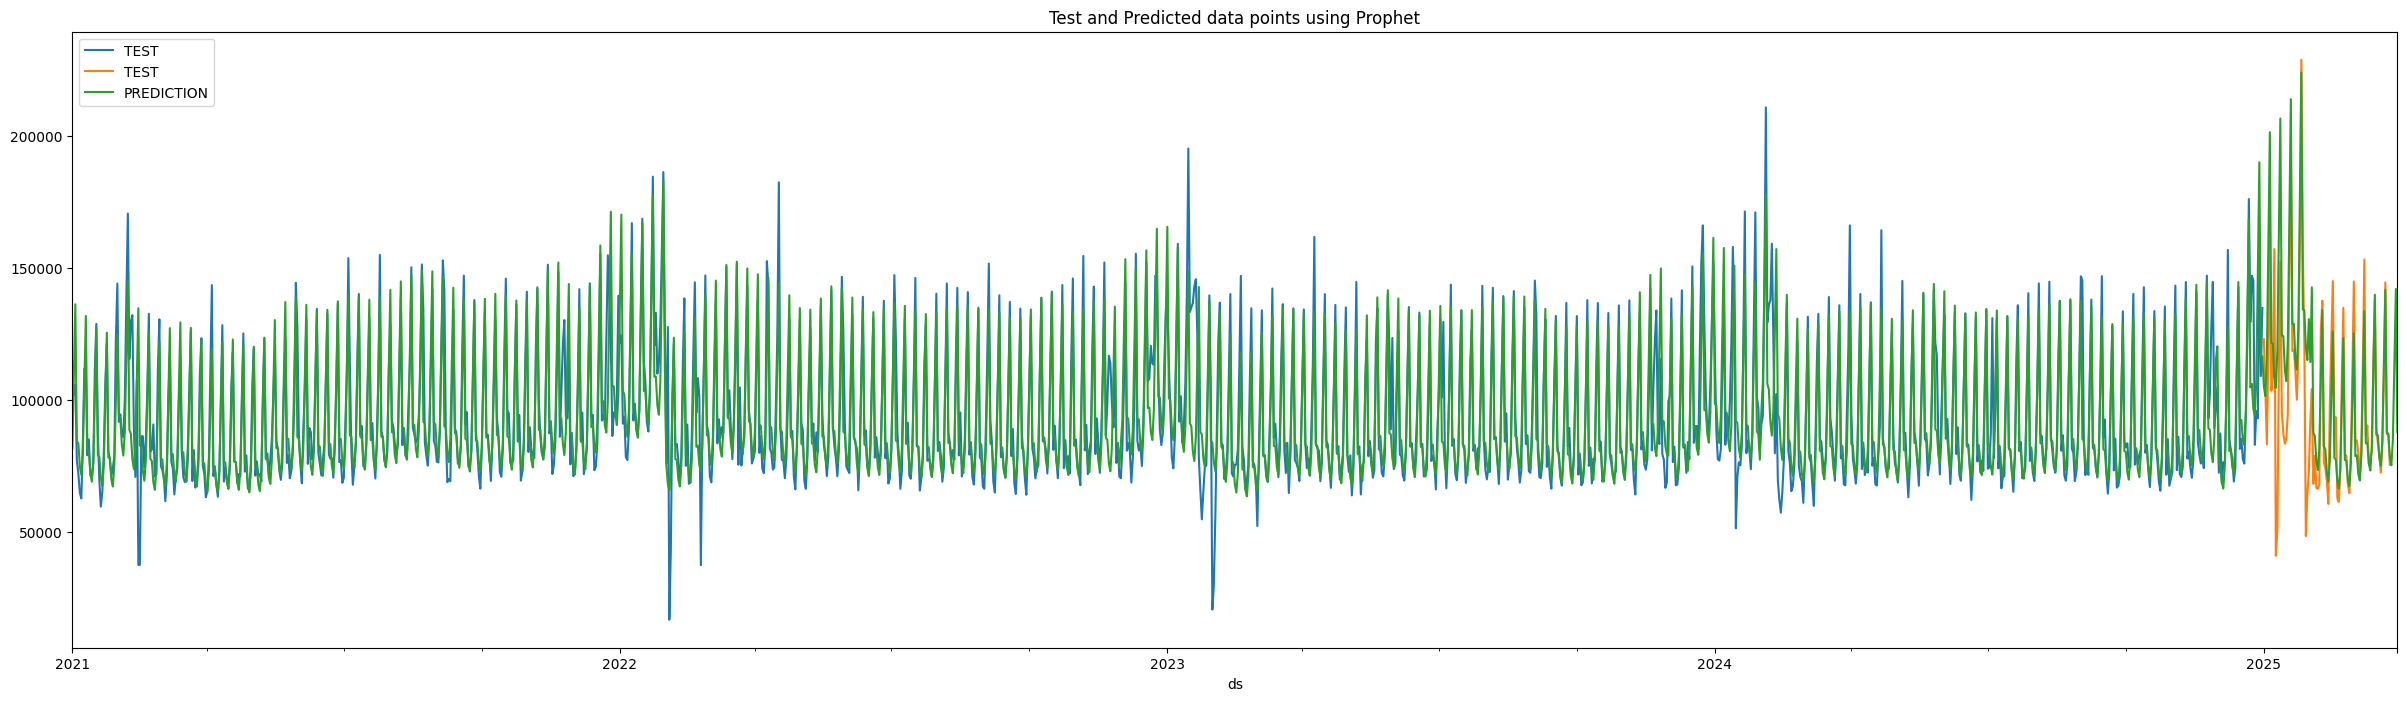

In [410]:
train.set_index('ds')['y'].plot(legend=True,label='TEST',figsize=(26,8))
test.set_index('ds')['y'].plot(legend=True,label='TEST',figsize=(26,8))
forecast.set_index('ds')['y_inv_boxcox'].plot(legend=True,label='PREDICTION',figsize=(30,8))
plt.title('Test and Predicted data points using Prophet')
plt.show()

In [293]:
df[df['sales']>160000]

,sales,sales_transformed
createddate,,
2021-02-07,170634.43,5.206400
2022-01-09,167006.28,5.203489
2022-01-16,168677.48,5.204839
2022-01-23,184584.51,5.216954
2022-01-30,186342.34,5.218218
2022-04-17,182456.30,5.215405
2023-01-15,195231.41,5.224402
2023-04-09,161793.28,5.199176
2023-12-24,166142.39,5.202785


In [407]:
forecast[forecast['y_inv_boxcox']>160000]

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,apr,apr_lower,apr_upper,dec_jan,...,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat,y_inv_boxcox
359,2021-12-26,5.068981,5.181020,5.234006,5.068981,5.068981,0.000000,0.000000,0.000000,0.008007,...,0.011938,0.011938,0.007268,0.007268,0.007268,0.0,0.0,0.0,5.206926,171300.515182
366,2022-01-02,5.056701,5.178750,5.232907,5.056701,5.056701,0.000000,0.000000,0.000000,0.010343,...,0.011938,0.011938,0.007259,0.007259,0.007259,0.0,0.0,0.0,5.206081,170232.293909
380,2022-01-16,5.058643,5.177093,5.229994,5.058643,5.058643,0.000000,0.000000,0.000000,0.013126,...,0.011938,0.011938,0.003583,0.003583,0.003583,0.0,0.0,0.0,5.203560,167093.048721
387,2022-01-23,5.072866,5.186145,5.238278,5.072866,5.072866,0.000000,0.000000,0.000000,0.013219,...,0.011938,0.011938,0.002174,0.002174,0.002174,0.0,0.0,0.0,5.211515,177235.473893
394,2022-01-30,5.087088,5.190013,5.242109,5.087088,5.087088,0.000000,0.000000,0.000000,0.012393,...,0.011938,0.011938,0.000995,0.000995,0.000995,0.0,0.0,0.0,5.215927,183169.620248
723,2022-12-25,5.111222,5.174721,5.227626,5.111222,5.111222,0.000000,0.000000,0.000000,-0.001273,...,0.011938,0.011938,0.007045,0.007045,0.007045,0.0,0.0,0.0,5.201747,164877.328840
730,2023-01-01,5.112359,5.176205,5.230889,5.112359,5.112359,0.000000,0.000000,0.000000,-0.001750,...,0.011938,0.011938,0.007413,0.007413,0.007413,0.0,0.0,0.0,5.202346,165605.546676
1094,2023-12-31,5.138414,5.172208,5.224956,5.138414,5.138414,0.000000,0.000000,0.000000,-0.007682,...,0.011938,0.011938,0.007505,0.007505,0.007505,0.0,0.0,0.0,5.198851,161408.371645
1129,2024-02-04,5.144847,5.184257,5.237317,5.144847,5.144847,0.001148,0.001148,0.001148,0.000000,...,0.011938,0.011938,-0.000035,-0.000035,-0.000035,0.0,0.0,0.0,5.211996,177872.219134
1451,2024-12-22,5.119056,5.177971,5.230258,5.119056,5.119056,0.000000,0.000000,0.000000,-0.001615,...,0.011938,0.011938,0.006418,0.006418,0.006418,0.0,0.0,0.0,5.204759,168577.836581


In [408]:

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAPE: {mape:.2f}%')

MAE: 15744.679
RMSE: 23147.196
MAPE: 18.44%


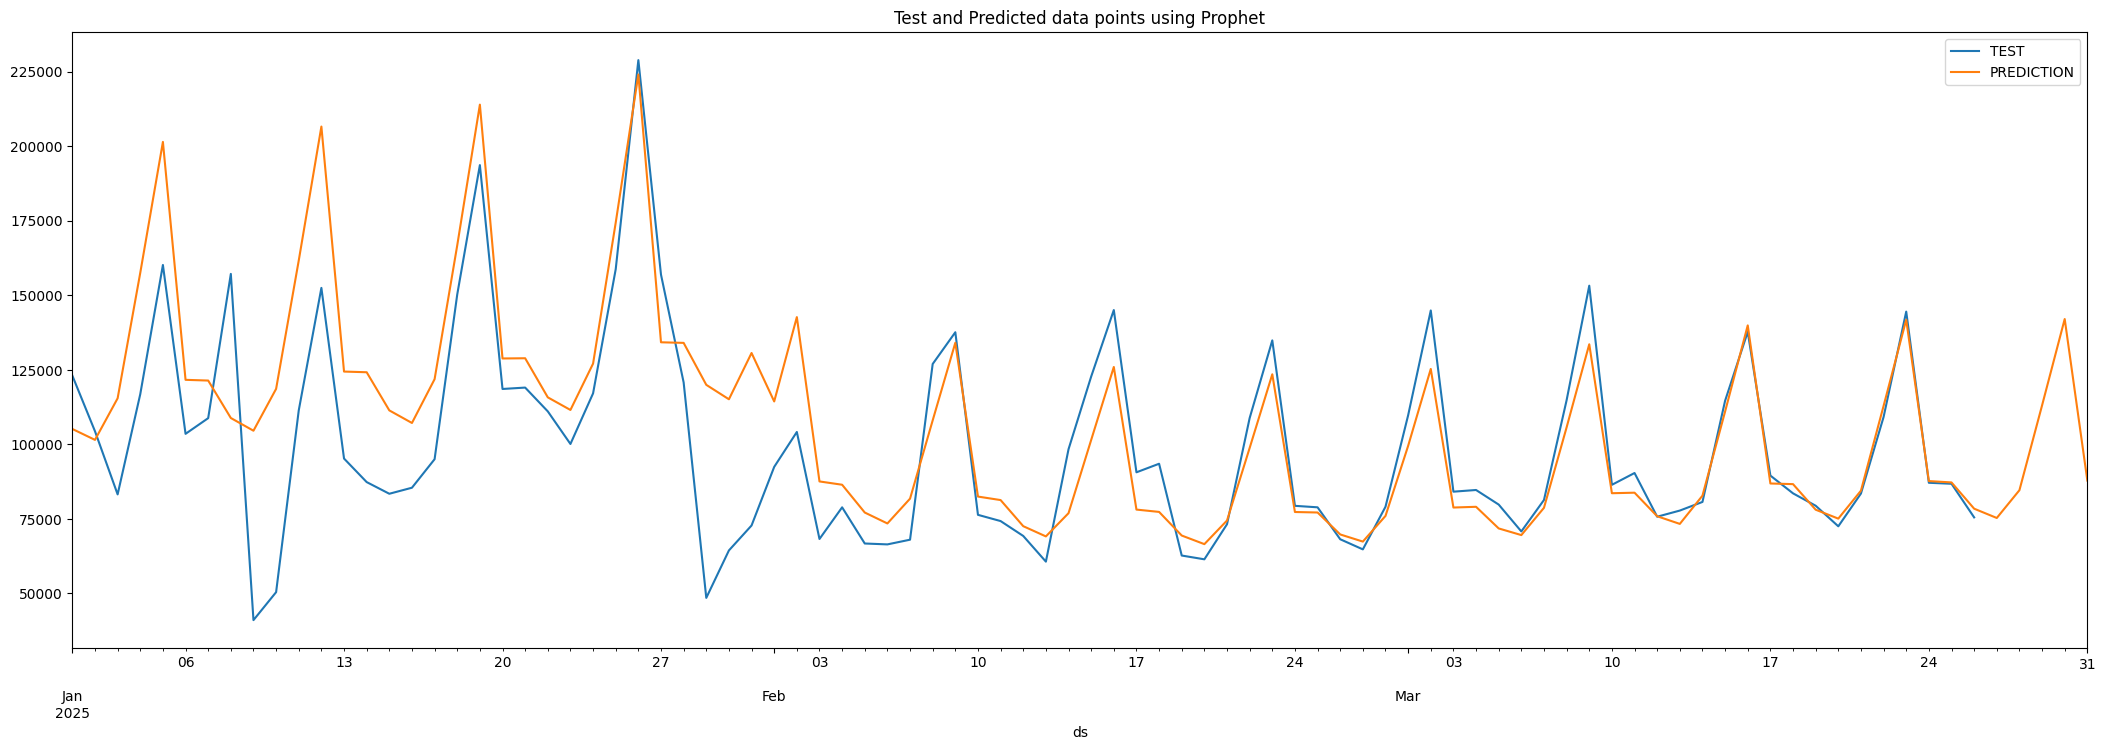

In [409]:
test.set_index('ds')['y'].plot(legend=True,label='TEST',figsize=(26,8))
forecast[forecast['ds']>'2024-12-31'].set_index('ds')['y_inv_boxcox'].plot(legend=True,label='PREDICTION',figsize=(26,8))
plt.title('Test and Predicted data points using Prophet')
plt.show()